# Feature Selection - Mutual Information & MRMR

This notebook performs feature selection on the insurance claims dataset using:
1. **Mutual Information** (sklearn) - measures dependency between features and target
2. **MRMR** (Minimum Redundancy Maximum Relevance) - selects features that are maximally relevant to the target while minimally redundant with each other

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif
import mrmr
import warnings
warnings.filterwarnings('ignore')

## 1. Load and Clean Data

In [2]:
df = pd.read_csv('../data/raw/insurance_claims.csv')
print(f"Original shape: {df.shape}")
df.head()

Original shape: (1000, 40)


,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,...,YES,71610,6510,13020,52080,Saab,92x,2004,Y,NaN
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,...,?,5070,780,780,3510,Mercedes,E400,2007,Y,NaN
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,...,NO,34650,7700,3850,23100,Dodge,RAM,2007,N,NaN
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,...,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y,NaN
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,...,NO,6500,1300,650,4550,Accura,RSX,2009,N,NaN


In [3]:
# Drop columns identified in data_overview as irrelevant/invalid
cols_to_drop = [
    'policy_number',       # identifier - no predictive value
    'policy_bind_date',    # date string - not useful directly
    'insured_zip',         # too many unique values, identifier-like
    'incident_location',   # too specific, high cardinality
    'incident_date',       # date string - not useful directly
    '_c39',                # 100% missing values (empty column)
]

df = df.drop(columns=cols_to_drop)
print(f"Shape after dropping irrelevant columns: {df.shape}")
print(f"\nDropped columns: {cols_to_drop}")

Shape after dropping irrelevant columns: (1000, 34)

Dropped columns: ['policy_number', 'policy_bind_date', 'insured_zip', 'incident_location', 'incident_date', '_c39']


## 2. Handle Missing/Invalid Values

In [4]:
# Replace '?' with NaN, then handle missing values
df.replace('?', np.nan, inplace=True)

# Check missing values after replacement
missing = df.isnull().sum()
missing = missing[missing > 0]
print("Missing values after replacing '?':")
print(missing)
print()

# For categorical columns with missing values, fill with mode
for col in ['collision_type', 'property_damage', 'police_report_available', 'authorities_contacted']:
    if col in df.columns:
        mode_val = df[col].mode()[0]
        df[col].fillna(mode_val, inplace=True)
        print(f"{col}: filled {missing.get(col, 0)} missing values with mode '{mode_val}'")

print(f"\nRemaining missing values: {df.isnull().sum().sum()}")

Missing values after replacing '?':
collision_type             178
authorities_contacted       91
property_damage            360
police_report_available    343
dtype: int64

collision_type: filled 178 missing values with mode 'Rear Collision'
property_damage: filled 360 missing values with mode 'NO'
police_report_available: filled 343 missing values with mode 'NO'
authorities_contacted: filled 91 missing values with mode 'Police'

Remaining missing values: 972


## 3. Encode Categorical Features

In [5]:
# Separate target
target_col = 'fraud_reported'
y = (df[target_col] == 'Y').astype(int)
X = df.drop(columns=[target_col])

# Label encode categorical features for MI calculation
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"Categorical features to encode: {len(categorical_cols)}")
print(f"Numerical features: {len(numerical_cols)}")
print(f"\nCategorical: {categorical_cols}")
print(f"\nNumerical: {numerical_cols}")

# Label encode
label_encoders = {}
X_encoded = X.copy()
for col in categorical_cols:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col].astype(str))
    label_encoders[col] = le

print(f"\nEncoded shape: {X_encoded.shape}")

Categorical features to encode: 17
Numerical features: 16

Categorical: ['policy_state', 'policy_csl', 'insured_sex', 'insured_education_level', 'insured_occupation', 'insured_hobbies', 'insured_relationship', 'incident_type', 'collision_type', 'incident_severity', 'authorities_contacted', 'incident_state', 'incident_city', 'property_damage', 'police_report_available', 'auto_make', 'auto_model']

Numerical: ['months_as_customer', 'age', 'policy_deductable', 'policy_annual_premium', 'umbrella_limit', 'capital-gains', 'capital-loss', 'incident_hour_of_the_day', 'number_of_vehicles_involved', 'bodily_injuries', 'witnesses', 'total_claim_amount', 'injury_claim', 'property_claim', 'vehicle_claim', 'auto_year']

Encoded shape: (1000, 33)


## 4. Mutual Information Feature Selection

In [6]:
# Identify which features are discrete (categorical) for MI calculation
discrete_mask = [col in categorical_cols for col in X_encoded.columns]

# Calculate mutual information scores
mi_scores = mutual_info_classif(
    X_encoded, y,
    discrete_features=discrete_mask,
    random_state=42,
    n_neighbors=5
)

# Create a DataFrame with MI scores
mi_df = pd.DataFrame({
    'Feature': X_encoded.columns,
    'MI_Score': mi_scores
}).sort_values('MI_Score', ascending=False).reset_index(drop=True)

print("Mutual Information Scores (sorted):")
print("=" * 50)
for _, row in mi_df.iterrows():
    bar = '#' * int(row['MI_Score'] * 100)
    print(f"{row['Feature']:<35} {row['MI_Score']:.4f}  {bar}")

Mutual Information Scores (sorted):
incident_severity                   0.1237  ############
insured_hobbies                     0.0724  #######
total_claim_amount                  0.0296  ##
auto_model                          0.0245  ##
collision_type                      0.0182  #
injury_claim                        0.0179  #
incident_type                       0.0172  #
auto_year                           0.0165  #
authorities_contacted               0.0154  #
property_claim                      0.0133  #
umbrella_limit                      0.0116  #
policy_annual_premium               0.0114  #
capital-loss                        0.0096  
capital-gains                       0.0091  
insured_occupation                  0.0088  
incident_state                      0.0079  
auto_make                           0.0070  
bodily_injuries                     0.0064  
vehicle_claim                       0.0060  
property_damage                     0.0041  
number_of_vehicles_involved      

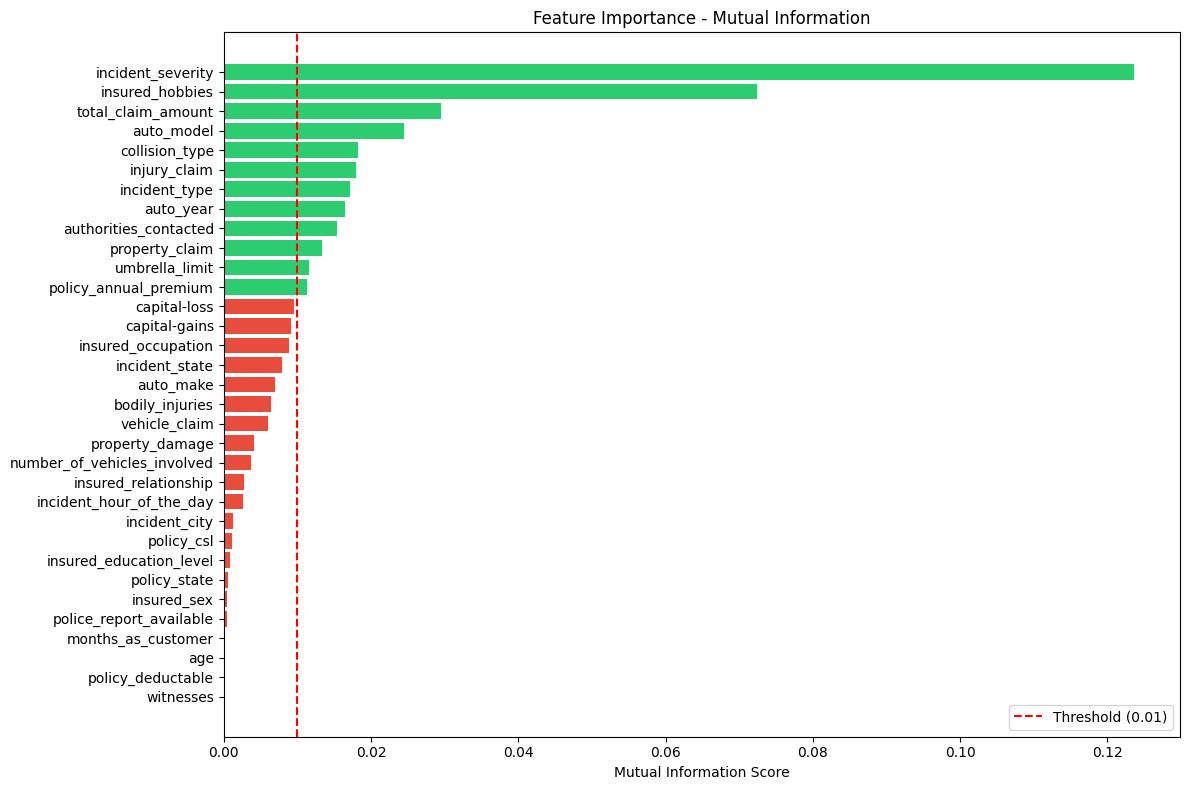


Features with MI < 0.01 (low relevance): ['capital-loss', 'capital-gains', 'insured_occupation', 'incident_state', 'auto_make', 'bodily_injuries', 'vehicle_claim', 'property_damage', 'number_of_vehicles_involved', 'insured_relationship', 'incident_hour_of_the_day', 'incident_city', 'policy_csl', 'insured_education_level', 'policy_state', 'insured_sex', 'police_report_available', 'months_as_customer', 'age', 'policy_deductable', 'witnesses']


In [7]:
# Visualize MI scores
plt.figure(figsize=(12, 8))
colors = ['#2ecc71' if score > 0.01 else '#e74c3c' for score in mi_df['MI_Score']]
plt.barh(range(len(mi_df)), mi_df['MI_Score'], color=colors)
plt.yticks(range(len(mi_df)), mi_df['Feature'])
plt.xlabel('Mutual Information Score')
plt.title('Feature Importance - Mutual Information')
plt.axvline(x=0.01, color='red', linestyle='--', label='Threshold (0.01)')
plt.legend()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Features with very low MI (candidates for removal)
low_mi_features = mi_df[mi_df['MI_Score'] < 0.01]['Feature'].tolist()
print(f"\nFeatures with MI < 0.01 (low relevance): {low_mi_features}")

## 5. MRMR Feature Selection

MRMR selects features that have high relevance to the target but low redundancy among themselves.

In [8]:
# Prepare DataFrame for MRMR (needs target as part of the dataframe)
df_mrmr = X_encoded.copy()
df_mrmr[target_col] = y

# Run MRMR - select top features
n_features_to_select = min(20, len(X_encoded.columns))

selected_features_mrmr = mrmr.mrmr_classif(
    X=df_mrmr.drop(columns=[target_col]),
    y=df_mrmr[target_col],
    K=n_features_to_select,
    show_progress=False
)

print(f"MRMR Selected Features (top {n_features_to_select}):")
print("=" * 50)
for i, feat in enumerate(selected_features_mrmr, 1):
    mi_score = mi_df[mi_df['Feature'] == feat]['MI_Score'].values[0]
    print(f"{i:>2}. {feat:<35} (MI: {mi_score:.4f})")

MRMR Selected Features (top 20):
 1. incident_severity                   (MI: 0.1237)
 2. umbrella_limit                      (MI: 0.0116)
 3. property_damage                     (MI: 0.0041)
 4. vehicle_claim                       (MI: 0.0060)
 5. witnesses                           (MI: 0.0000)
 6. total_claim_amount                  (MI: 0.0296)
 7. insured_hobbies                     (MI: 0.0724)
 8. collision_type                      (MI: 0.0182)
 9. incident_city                       (MI: 0.0013)
10. authorities_contacted               (MI: 0.0154)
11. property_claim                      (MI: 0.0133)
12. incident_state                      (MI: 0.0079)
13. policy_state                        (MI: 0.0005)
14. bodily_injuries                     (MI: 0.0064)
15. insured_sex                         (MI: 0.0005)
16. policy_csl                          (MI: 0.0011)
17. injury_claim                        (MI: 0.0179)
18. auto_make                           (MI: 0.0070)
19. number_of

In [9]:
# Compare MI ranking vs MRMR ranking
mi_top = mi_df.head(n_features_to_select)['Feature'].tolist()

print("Comparison: MI vs MRMR Rankings")
print("=" * 70)
print(f"{'Rank':<6} {'MI Top Features':<35} {'MRMR Top Features':<35}")
print("-" * 70)
for i in range(n_features_to_select):
    mi_feat = mi_top[i] if i < len(mi_top) else '-'
    mrmr_feat = selected_features_mrmr[i] if i < len(selected_features_mrmr) else '-'
    marker = ' *' if mi_feat != mrmr_feat else ''
    print(f"{i+1:<6} {mi_feat:<35} {mrmr_feat:<35}{marker}")

# Features in both
common = set(mi_top) & set(selected_features_mrmr)
only_mi = set(mi_top) - set(selected_features_mrmr)
only_mrmr = set(selected_features_mrmr) - set(mi_top)

print(f"\nFeatures in both: {len(common)}")
print(f"Only in MI top: {only_mi}")
print(f"Only in MRMR top: {only_mrmr}")

Comparison: MI vs MRMR Rankings
Rank   MI Top Features                     MRMR Top Features                  
----------------------------------------------------------------------
1      incident_severity                   incident_severity                  
2      insured_hobbies                     umbrella_limit                      *
3      total_claim_amount                  property_damage                     *
4      auto_model                          vehicle_claim                       *
5      collision_type                      witnesses                           *
6      injury_claim                        total_claim_amount                  *
7      incident_type                       insured_hobbies                     *
8      auto_year                           collision_type                      *
9      authorities_contacted               incident_city                       *
10     property_claim                      authorities_contacted               *
11     umb

## 6. Final Feature Selection

In [10]:
# Use MRMR selected features as the final selection
# (MRMR accounts for both relevance AND redundancy)
final_features = selected_features_mrmr

print(f"Final selected features ({len(final_features)}):")
print("=" * 50)
for i, feat in enumerate(final_features, 1):
    feat_type = 'categorical' if feat in categorical_cols else 'numerical'
    mi_score = mi_df[mi_df['Feature'] == feat]['MI_Score'].values[0]
    print(f"{i:>2}. {feat:<35} ({feat_type:<12}) MI={mi_score:.4f}")

# Save selected features to processed data
selected_df = df[final_features + [target_col]]
selected_df.to_csv('../data/processed/selected_features.csv', index=False)
print(f"\nSaved selected features dataset to data/processed/selected_features.csv")
print(f"Shape: {selected_df.shape}")

Final selected features (20):
 1. incident_severity                   (categorical ) MI=0.1237
 2. umbrella_limit                      (numerical   ) MI=0.0116
 3. property_damage                     (categorical ) MI=0.0041
 4. vehicle_claim                       (numerical   ) MI=0.0060
 5. witnesses                           (numerical   ) MI=0.0000
 6. total_claim_amount                  (numerical   ) MI=0.0296
 7. insured_hobbies                     (categorical ) MI=0.0724
 8. collision_type                      (categorical ) MI=0.0182
 9. incident_city                       (categorical ) MI=0.0013
10. authorities_contacted               (categorical ) MI=0.0154
11. property_claim                      (numerical   ) MI=0.0133
12. incident_state                      (categorical ) MI=0.0079
13. policy_state                        (categorical ) MI=0.0005
14. bodily_injuries                     (numerical   ) MI=0.0064
15. insured_sex                         (categorical ) MI=0.

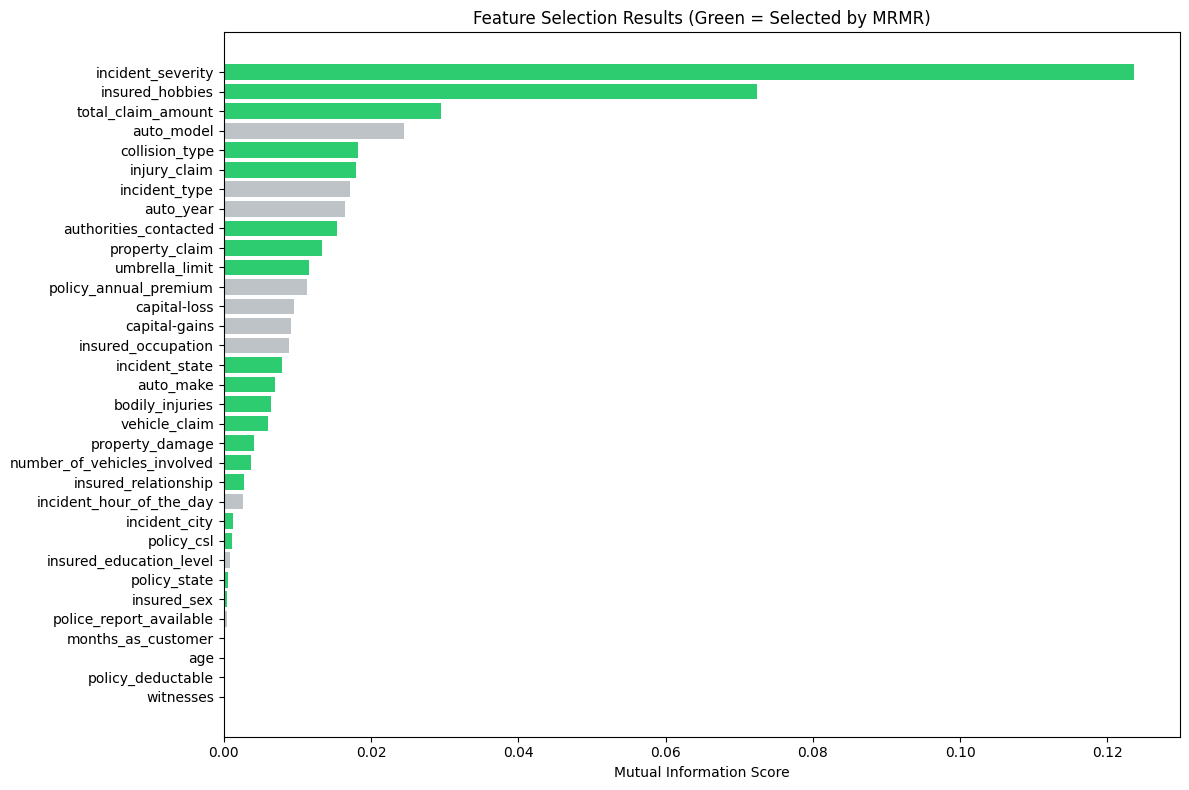


Dropped features (13): ['months_as_customer', 'age', 'policy_deductable', 'policy_annual_premium', 'insured_education_level', 'insured_occupation', 'capital-gains', 'capital-loss', 'incident_type', 'incident_hour_of_the_day', 'police_report_available', 'auto_model', 'auto_year']


In [11]:
# Visualize: side-by-side MI scores for selected vs dropped features
mi_df['Selected'] = mi_df['Feature'].isin(final_features)

plt.figure(figsize=(12, 8))
colors = ['#2ecc71' if sel else '#bdc3c7' for sel in mi_df['Selected']]
plt.barh(range(len(mi_df)), mi_df['MI_Score'], color=colors)
plt.yticks(range(len(mi_df)), mi_df['Feature'])
plt.xlabel('Mutual Information Score')
plt.title('Feature Selection Results (Green = Selected by MRMR)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Summary
dropped_features = [f for f in X_encoded.columns if f not in final_features]
print(f"\nDropped features ({len(dropped_features)}): {dropped_features}")